In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import random
from sklearn.metrics import confusion_matrix
import os
from scipy.ndimage import binary_dilation, binary_erosion

In [ ]:
base_dir = r"C:\Users\cambo\Desktop\Subglacial_Lakes_Data"
checkpoint_path = b'boundary_weighted_model.pth' # Best model using the boundary-weighted loss function
createNew = False # Set to True to create new checkpoint file, False to load existing one

In [7]:
# ============================================
# LOSS FUNCTIONS & UTILITIES
# ============================================

# ============================================
# DICE LOSS
# ============================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum()
        union = probs.sum() + targets.sum()
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice

# ============================================
# BOUNDARY-WEIGHTED LOSS
# ============================================
class BoundaryWeightedLoss(nn.Module):
    def __init__(self, pos_weight=None, boundary_weight=0.3, boundary_width=5):
        super().__init__()
        self.pos_weight = pos_weight
        self.boundary_weight = boundary_weight
        self.boundary_width = boundary_width
        
    def forward(self, logits, targets):
        boundaries = self._get_boundaries(targets)
        weight_map = torch.ones_like(targets)
        weight_map[boundaries] = self.boundary_weight
        
        if self.pos_weight is not None:
            pos_mask = (targets > 0).float()
            weight_map = weight_map * (1 + (self.pos_weight - 1) * pos_mask)
        
        loss = F.binary_cross_entropy_with_logits(logits, targets, weight=weight_map, reduction='mean')
        return loss
    
    def _get_boundaries(self, masks):
        masks_np = masks.cpu().numpy()
        boundaries = np.zeros_like(masks_np)
        for i in range(masks_np.shape[0]):
            for j in range(masks_np.shape[1]):
                mask = masks_np[i, j]
                dilated = binary_dilation(mask, iterations=self.boundary_width)
                eroded = binary_erosion(mask, iterations=self.boundary_width)
                boundaries[i, j] = dilated.astype(int) - eroded.astype(int)
        return torch.tensor(boundaries, dtype=torch.bool).to(masks.device)

# ============================================
# AUGMENTATIONS
# ============================================
def random_crop(img, mask, crop_size=448):
    _, h, w = img.shape
    crop_size = min(crop_size, h, w)
    y = random.randint(0, h - crop_size)
    x = random.randint(0, w - crop_size)
    img_cropped = img[:, y:y+crop_size, x:x+crop_size]
    mask_cropped = mask[:, y:y+crop_size, x:x+crop_size]
    return img_cropped, mask_cropped

def augment_batch(X, y):
    # Random crop
    if random.random() > 0.5:
        cropped_X = []
        cropped_y = []
        for i in range(X.shape[0]):
            img_crop, mask_crop = random_crop(X[i], y[i], crop_size=448)
            cropped_X.append(img_crop)
            cropped_y.append(mask_crop)
        X = torch.stack(cropped_X)
        y = torch.stack(cropped_y)

    # Spatial transforms
    if random.random() > 0.5:
        X = torch.flip(X, dims=[3])
        y = torch.flip(y, dims=[3])
    if random.random() > 0.5:
        X = torch.flip(X, dims=[2])
        y = torch.flip(y, dims=[2])
    if random.random() > 0.5:
        k = random.randint(1, 3)
        X = torch.rot90(X, k, dims=[2, 3])
        y = torch.rot90(y, k, dims=[2, 3])

    return X, y

# ============================================
# BALANCED BATCH SAMPLER
# ============================================
class BalancedBatchSampler(Sampler):
    def __init__(self, lake_indices, null_indices, batch_size, lake_ratio=0.5):
        self.lake_indices = lake_indices
        self.null_indices = null_indices
        self.batch_size = batch_size
        self.lake_ratio = lake_ratio
        self.lake_per_batch = int(batch_size * lake_ratio)
        self.null_per_batch = batch_size - self.lake_per_batch
        self.num_batches = min(len(lake_indices) // self.lake_per_batch,
                               len(null_indices) // self.null_per_batch)

    def __iter__(self):
        lake_cycle = self._cycle(self.lake_indices)
        null_cycle = self._cycle(self.null_indices)
        for _ in range(self.num_batches * self.batch_size):
            if (_ % self.batch_size) < self.lake_per_batch:
                yield next(lake_cycle)
            else:
                yield next(null_cycle)

    def _cycle(self, indices):
        while True:
            shuffled = indices.copy()
            random.shuffle(shuffled)
            for idx in shuffled:
                yield idx

    def __len__(self):
        return self.num_batches * self.batch_size

# ============================================
# METRICS
# ============================================
def dice_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    total = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    union = total - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

@torch.no_grad()
def quick_check(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(y.cpu().numpy().flatten())
    cm = confusion_matrix(all_targets, all_preds)
    tn, fp, fn, tp = cm.ravel()
    print(f"TN: {tn}, FP: {fp}")
    print(f"FN: {fn}, TP: {tp}")
    print(f"False positive rate: {fp/(fp+tn):.4f}")

# ============================================
# EVALUATION FUNCTION
# ============================================
@torch.no_grad()
def evaluate_segmentation(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_batches = 0
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        logits = model(X)
        probs = torch.sigmoid(logits)
        print(f"Batch {n_batches}:")
        print(f"  Probability range: {probs.min():.4f} - {probs.max():.4f}")
        print(f"  Mean probability: {probs.mean():.4f}")
        print(f"  Predictions >0.1: {(probs > 0.1).float().mean():.4f}")
        print(f"  Predictions >0.5: {(probs > 0.5).float().mean():.4f}")
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_dice += dice_score_from_logits(logits, y)
        total_iou += iou_score_from_logits(logits, y)
        n_batches += 1
    return {"loss": total_loss / n_batches, "dice": total_dice / n_batches, "iou": total_iou / n_batches}

# ============================================
# CREATE BALANCED LOADER
# ============================================
def create_balanced_loader(train_dataset, batch_size=4, lake_ratio=0.5):
    lake_indices = []
    null_indices = []
    for i in range(len(train_dataset)):
        _, mask = train_dataset[i]
        if (mask == 1).any():
            lake_indices.append(i)
        else:
            null_indices.append(i)
    balanced_sampler = BalancedBatchSampler(lake_indices, null_indices, batch_size, lake_ratio)
    balanced_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=balanced_sampler,
                                 num_workers=0, pin_memory=False, drop_last=True)
    return balanced_loader, lake_indices, null_indices

In [8]:
# ============================================
# BLOCK 2: DATA LOADING AND PATCH DATASET
# ============================================
lake_location_path = os.path.join(base_dir, "lake_locations.csv")
lake_and_null_path = os.path.join(base_dir, "lake_and_null_loc.csv")
dataset_split_path = os.path.join(base_dir, "dataset_split.csv")
lake_masks = os.path.join(base_dir, "lake_masks")
training_set = os.path.join(base_dir, "lakesTS_2")

lake_location = pd.read_csv(lake_location_path)
lake_and_null = pd.read_csv(lake_and_null_path)
dataset_split = pd.read_csv(dataset_split_path)

tile_files = sorted([f for f in os.listdir(training_set) if f.endswith(".nc")])
mask_files = sorted([f for f in os.listdir(lake_masks) if f.endswith(".nc")])

print("number of training files:", len(tile_files))
print("number of lake mask files:", len(mask_files))

rows = []
for tile in tile_files:
    name = tile.replace(".nc", "")
    tile_path = os.path.join(training_set, tile)
    mask_file = f"{name}_mask.nc"
    mask_path = os.path.join(lake_masks, mask_file)
    if os.path.exists(mask_path):
        has_mask = True
    else:
        mask_path = None
        has_mask = False
    rows.append({"name": name, "tile_path": tile_path, "mask_path": mask_path, "has_lake": int(has_mask)})

dataset_df = pd.DataFrame(rows)

dataset_split["file_name"] = (dataset_split["file"].astype(str).str.strip()
                               .str.replace("\\", "/", regex=False).str.split("/").str[-1])
dataset_split["name"] = dataset_split["file_name"].str.replace(".nc", "", regex=False)
dataset_df = dataset_df.merge(dataset_split[["name", "dataset"]], on="name", how="left")

train_df = dataset_df[dataset_df["dataset"] == "train"].reset_index(drop=True)
val_df = dataset_df[dataset_df["dataset"] == "val"].reset_index(drop=True)
test_df = dataset_df[dataset_df["dataset"] == "test"].reset_index(drop=True)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ============================================
# PATCH DATASET CLASS
# ============================================
class PatchLakeDataset(Dataset):
    def __init__(self, dataframe, tile_var="anomaly", mask_var="lake_mask", 
                 patch_size=256, stride=128, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.tile_var = tile_var
        self.mask_var = mask_var
        self.patch_size = patch_size
        self.stride = stride
        self.augment = augment
        self.patches = []
        print("Generating patches...")
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            X, _ = self._load_image_mask(row, return_mask=False)
            h, w = X.shape[1], X.shape[2]
            for y in range(0, h - patch_size + 1, stride):
                for x in range(0, w - patch_size + 1, stride):
                    self.patches.append({'idx': idx, 'y': y, 'x': x})
        print(f"Created {len(self.patches)} patches from {len(self.df)} images")

    def _load_image_mask(self, row, return_mask=True):
        tile_path = str(row["tile_path"])
        tile_ds = xr.open_dataset(tile_path, engine='netcdf4')
        arr = tile_ds[self.tile_var].values.astype(np.float32)
        tile_ds.close()
        valid = np.isfinite(arr)
        valid_count = valid.sum(axis=0)
        arr_zeroed = np.where(valid, arr, 0.0)
        mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
        diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
        std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
        mean_img[valid_count == 0] = 0.0
        std_img[valid_count == 0] = 0.0
        x = np.stack([mean_img, std_img], axis=0)
        GLOBAL_MEAN_MEAN = -2.4824232087901197
        GLOBAL_STD_MEAN = 20.268677019954087
        GLOBAL_STD_STD = 3.7701363263330427
        x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN
        x[1] = x[1] / GLOBAL_STD_STD
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        if not return_mask:
            return torch.tensor(x, dtype=torch.float32), None
        if pd.isna(row["mask_path"]) or row["mask_path"] is None:
            mask = np.zeros((x.shape[1], x.shape[2]), dtype=np.float32)
        else:
            mask_path = str(row["mask_path"])
            mask_ds = xr.open_dataset(mask_path, engine='netcdf4')
            mask = mask_ds[self.mask_var].values.astype(np.float32)
            mask_ds.close()
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch_info = self.patches[idx]
        X, mask = self._load_image_mask(self.df.iloc[patch_info['idx']])
        y, x = patch_info['y'], patch_info['x']
        ps = self.patch_size
        X_patch = X[:, y:y+ps, x:x+ps]
        mask_patch = mask[:, y:y+ps, x:x+ps]
        if self.augment:
            if random.random() > 0.5:
                X_patch = torch.flip(X_patch, dims=[2])
                mask_patch = torch.flip(mask_patch, dims=[2])
            if random.random() > 0.5:
                X_patch = torch.flip(X_patch, dims=[1])
                mask_patch = torch.flip(mask_patch, dims=[1])
            if random.random() > 0.5:
                k = random.randint(1, 3)
                X_patch = torch.rot90(X_patch, k, dims=[1, 2])
                mask_patch = torch.rot90(mask_patch, k, dims=[1, 2])
        return X_patch, mask_patch

# ============================================
# CREATE DATASETS
# ============================================
patch_size = 256
stride = 128

train_dataset = PatchLakeDataset(train_df, patch_size=patch_size, stride=stride, augment=True)
val_dataset = PatchLakeDataset(val_df, patch_size=patch_size, stride=stride, augment=False)
test_dataset = PatchLakeDataset(test_df, patch_size=patch_size, stride=stride, augment=False)

print(f"Training patches: {len(train_dataset)}")
print(f"Validation patches: {len(val_dataset)}")
print(f"Test patches: {len(test_dataset)}")

# ============================================
# CREATE DATALOADERS
# ============================================
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

X_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: {X_batch.shape}")

number of training files: 105
number of lake mask files: 85
Generating patches...
Created 292 patches from 73 images
Generating patches...
Created 64 patches from 16 images
Generating patches...
Created 64 patches from 16 images
Training patches: 292
Validation patches: 64
Test patches: 64
Batch shape: torch.Size([16, 2, 256, 256])


In [9]:
# ============================================
# BLOCK 3: UNET MODEL
# ============================================

class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Dropout2d(0.2),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Dropout2d(0.2)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = conv_block(256, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.final = nn.Conv2d(64, out_channels, 1)

    def _match_size(self, src, target):
        if src.shape[-2:] != target.shape[-2:]:
            src = F.interpolate(src, size=target.shape[-2:], mode="bilinear", align_corners=False)
        return src

    def forward(self, x):
        e1 = self.enc1(x)                  # [B, 64, 256, 256]
        e2 = self.enc2(self.pool1(e1))     # [B, 128, 128, 128]
        e3 = self.enc3(self.pool2(e2))     # [B, 256, 64, 64]
        b = self.bottleneck(self.pool3(e3))  # [B, 512, 32, 32]
        d3 = self.up3(b)
        d3 = self._match_size(d3, e3)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = self._match_size(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = self._match_size(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        out = self.final(d1)
        out = self._match_size(out, x)
        return out

def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# ============================================
# TRAIN ONE EPOCH
# ============================================
def train_one_epoch(model, loader, criterion, optimizer, device, alpha=0.7, bce=None, dice_loss=None):
    model.train()
    total_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        X, y = augment_batch(X, y)
        optimizer.zero_grad()
        logits = model(X)
        loss = alpha * bce(logits, y) + (1-alpha) * dice_loss(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

Batch 0:
  Probability range: 0.0179 - 0.9999
  Mean probability: 0.5522
  Predictions >0.1: 1.0000
  Predictions >0.5: 0.8762
Batch 1:
  Probability range: 0.0298 - 0.9845
  Mean probability: 0.5355
  Predictions >0.1: 1.0000
  Predictions >0.5: 0.8131
Batch 2:
  Probability range: 0.1210 - 0.8141
  Mean probability: 0.5244
  Predictions >0.1: 1.0000
  Predictions >0.5: 0.7195
Batch 3:
  Probability range: 0.4130 - 0.6477
  Mean probability: 0.5493
  Predictions >0.1: 1.0000
  Predictions >0.5: 0.9296
Epoch 1/50 | Train Loss: 0.8638 | Val Loss: 0.9214 | Val Dice: 0.1016
*** New best model saved! Dice: 0.1016 ***
Batch 0:
  Probability range: 0.0056 - 1.0000
  Mean probability: 0.4801
  Predictions >0.1: 0.9998
  Predictions >0.5: 0.4983
Batch 1:
  Probability range: 0.0103 - 0.9998
  Mean probability: 0.4306
  Predictions >0.1: 0.9999
  Predictions >0.5: 0.3848
Batch 2:
  Probability range: 0.0605 - 0.9785
  Mean probability: 0.3821
  Predictions >0.1: 1.0000
  Predictions >0.5: 0.268

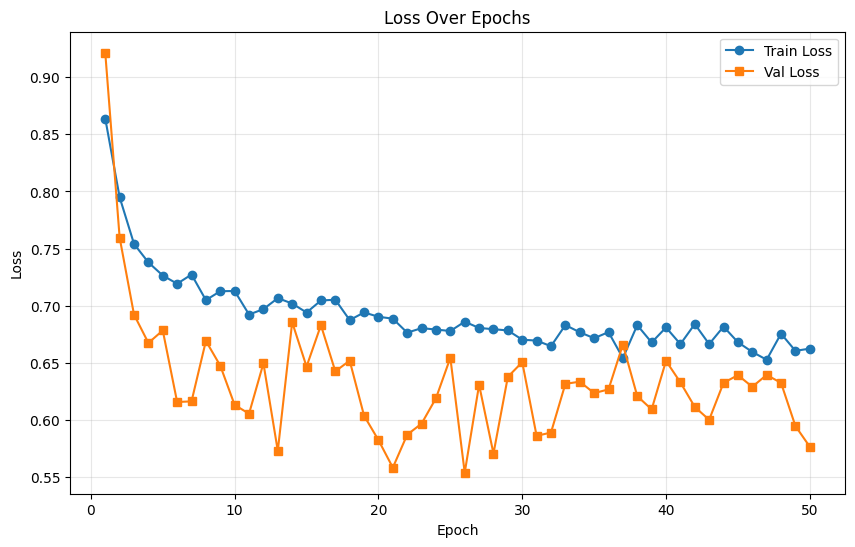

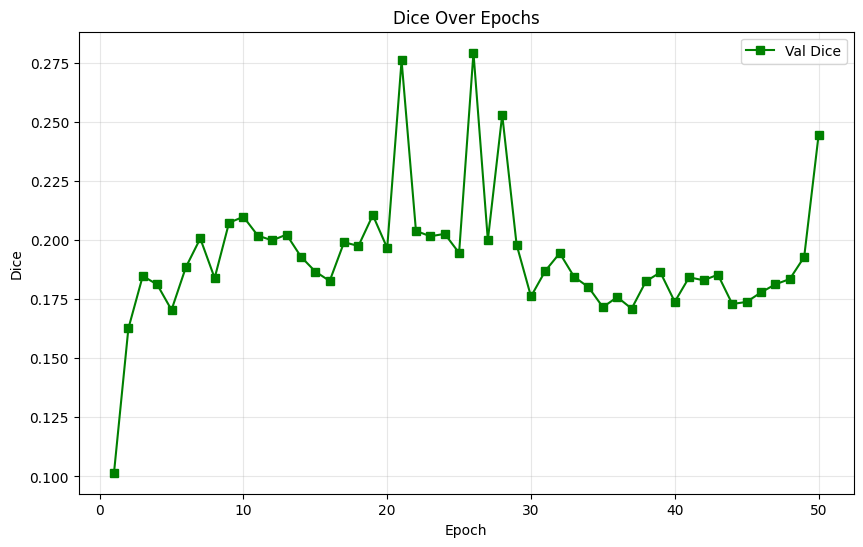


Best Dice: 0.2792


In [10]:
# ============================================
# BLOCK 4: TRAINING LOOP (Boundary-Weighted)
# ============================================
if createNew == True:
    train_losses = []
    val_losses = []
    val_dice_scores = []
    best_dice = 0
    num_epochs = 50

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet(in_channels=2, out_channels=1).to(device)
    model.apply(init_weights)

    bce_weighted = BoundaryWeightedLoss(pos_weight=torch.tensor([8.0]).to(device), boundary_weight=0.3, boundary_width=5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([8.0]).to(device))
    dice_loss = DiceLoss()
    alpha = 0.7

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)

    import torch.optim.lr_scheduler as lr_scheduler
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            X, y = augment_batch(X, y)
            optimizer.zero_grad()
            logits = model(X)
            loss = alpha * bce_weighted(logits, y) + (1-alpha) * dice_loss(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X.size(0)
        train_loss = total_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        val_results = evaluate_segmentation(model, val_loader, bce_weighted, device)
        val_losses.append(val_results['loss'])
        val_dice_scores.append(val_results['dice'])

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_results['loss']:.4f} | Val Dice: {val_results['dice']:.4f}")

        if val_results['dice'] > best_dice:
            best_dice = val_results['dice']
            torch.save(model.state_dict(), f'best_lake_model_epoch{epoch+1}_dice{best_dice:.3f}.pth')
            print(f"*** New best model saved! Dice: {best_dice:.4f} ***")

        if (epoch + 1) % 10 == 0:
            print(f"\n{'='*60}")
            print(f"CONFUSION MATRIX AT EPOCH {epoch+1}")
            print(f"{'='*60}")
            quick_check(model, val_loader, device)
            print(f"{'='*60}\n")

        scheduler.step(val_results['dice'])

    # Plotting
    plt.figure(figsize=(10,6))
    plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10,6))
    plt.plot(range(1, num_epochs+1), val_dice_scores, label='Val Dice', color='green', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Dice')
    plt.title('Dice Over Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nBest Dice: {best_dice:.4f}")

else:
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Recreate the model architecture (must match the saved model)
    model = UNet(in_channels=2, out_channels=1).to(device)
    # Load the saved weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))



Reconstructing full image for validation sample index 3 -> Borchgrevink198
  Reconstructing 501x501 image with 3x3 patches...


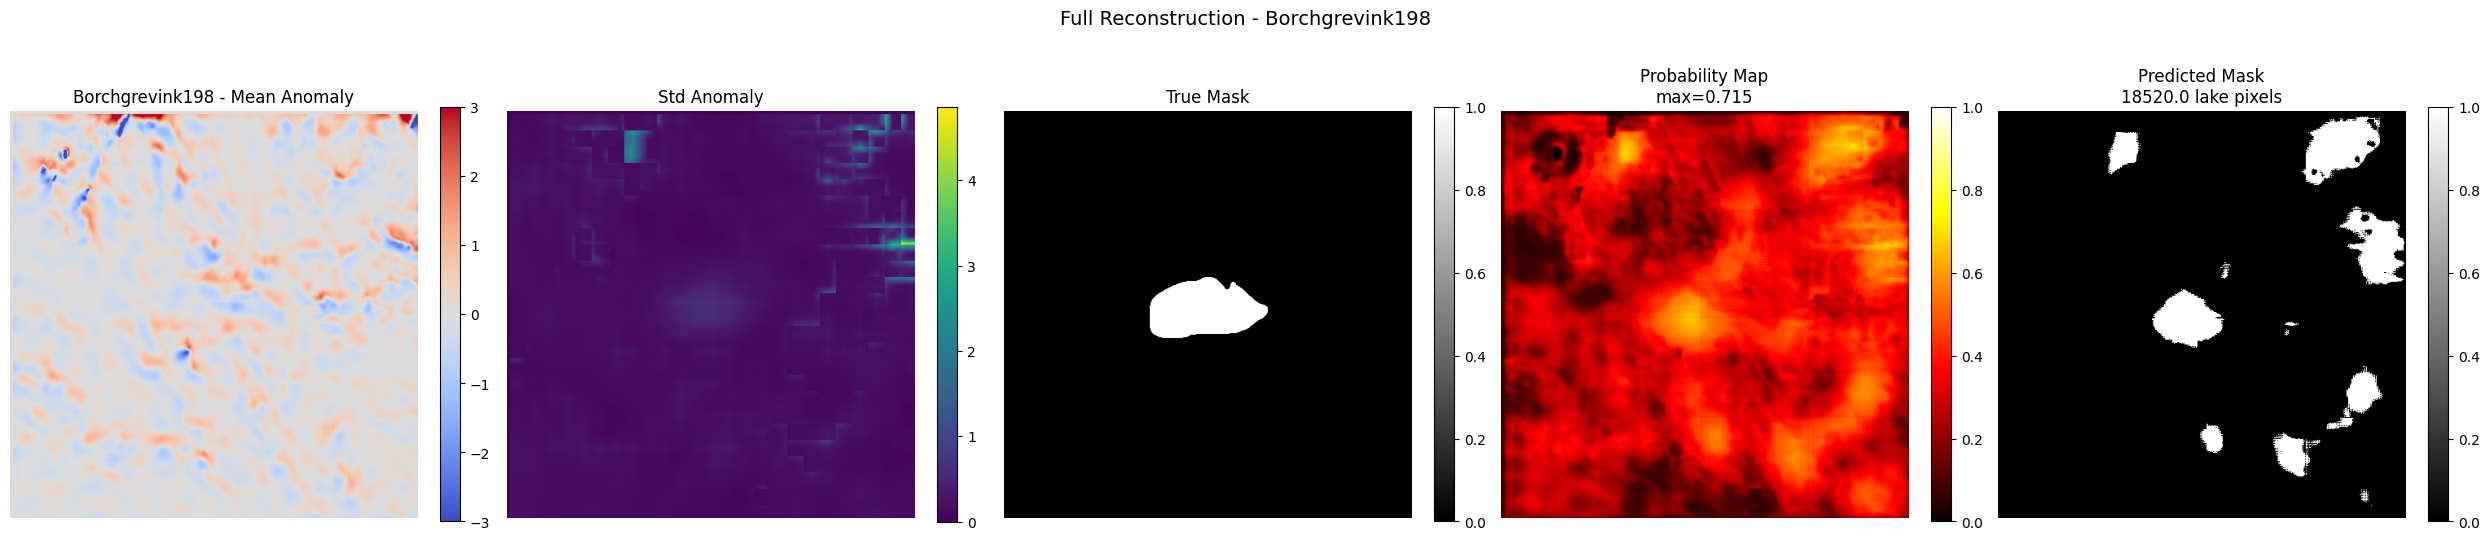

  Dice: 0.2584


In [ ]:
# ============================================
# BLOCK 5: FULL IMAGE RECONSTRUCTION
# ============================================

def reconstruct_full_image(model, full_image_tensor, patch_size=256, stride=128, device='cuda', threshold=0.5):
    model.eval()
    C, H, W = full_image_tensor.shape
    import math
    n_y = math.ceil((H - patch_size) / stride) + 1
    n_x = math.ceil((W - patch_size) / stride) + 1
    stride_y = stride
    stride_x = stride
    if n_y > 1:
        stride_y = (H - patch_size) / (n_y - 1)
    if n_x > 1:
        stride_x = (W - patch_size) / (n_x - 1)
    prob_accumulator = torch.zeros((H, W)).to(device)
    weight_accumulator = torch.zeros((H, W)).to(device)

    def get_gaussian_weights(patch_size):
        center = patch_size // 2
        y, x = torch.meshgrid(torch.arange(patch_size), torch.arange(patch_size), indexing='ij')
        gaussian = torch.exp(-((x - center)**2 + (y - center)**2) / (2 * (patch_size/4)**2))
        return gaussian / gaussian.max()

    gaussian_weights = get_gaussian_weights(patch_size).to(device)
    print(f"  Reconstructing {H}x{W} image with {n_y}x{n_x} patches...")

    with torch.no_grad():
        for i in range(n_y):
            for j in range(n_x):
                y = min(int(i * stride_y), H - patch_size)
                x = min(int(j * stride_x), W - patch_size)
                patch = full_image_tensor[:, y:y+patch_size, x:x+patch_size].unsqueeze(0).to(device)
                logits = model(patch)
                probs = torch.sigmoid(logits).squeeze().cpu()
                weighted_probs = probs * gaussian_weights.cpu()
                prob_accumulator[y:y+patch_size, x:x+patch_size] += weighted_probs
                weight_accumulator[y:y+patch_size, x:x+patch_size] += gaussian_weights.cpu()

    weight_accumulator = torch.clamp(weight_accumulator, min=1e-8)
    averaged_probs = prob_accumulator / weight_accumulator
    full_pred = (averaged_probs > threshold).float()
    return full_pred.cpu(), averaged_probs.cpu()

def load_full_image(row, device='cuda'):
    tile_path = str(row["tile_path"])
    tile_ds = xr.open_dataset(tile_path, engine='netcdf4')
    arr = tile_ds["anomaly"].values.astype(np.float32)
    tile_ds.close()
    valid = np.isfinite(arr)
    valid_count = valid.sum(axis=0)
    arr_zeroed = np.where(valid, arr, 0.0)
    mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
    diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
    std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
    mean_img[valid_count == 0] = 0.0
    std_img[valid_count == 0] = 0.0
    x = np.stack([mean_img, std_img], axis=0)
    GLOBAL_MEAN_MEAN = -2.4824232087901197
    GLOBAL_STD_MEAN = 20.268677019954087
    GLOBAL_STD_STD = 3.7701363263330427
    x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN
    x[1] = x[1] / GLOBAL_STD_STD
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    if not pd.isna(row["mask_path"]):
        mask_path = str(row["mask_path"])
        mask_ds = xr.open_dataset(mask_path, engine='netcdf4')
        true_mask = mask_ds["lake_mask"].values.astype(np.float32)
        mask_ds.close()
        true_mask = (true_mask > 0).astype(np.float32)
        true_mask = torch.tensor(true_mask)
        has_lake = True
    else:
        true_mask = None
        has_lake = False
    return torch.tensor(x, dtype=torch.float32), true_mask, row['name'], has_lake

def plot_full_reconstruction_simple(sample_idx, model, val_df, val_dataset, device,
                                    patch_size=256, stride=128, threshold=0.5):
    patch_info = val_dataset.patches[sample_idx]
    original_idx = patch_info['idx']
    row = val_df.iloc[original_idx]
    sample_name = row['name']
    print(f"\nReconstructing full image for validation sample index {sample_idx} -> {sample_name}")
    full_image, true_mask, name, has_lake = load_full_image(row, device)
    pred_mask, confidence = reconstruct_full_image(model, full_image, patch_size, stride, device, threshold)

    fig, axes = plt.subplots(1, 5, figsize=(25,6))
    im0 = axes[0].imshow(full_image[0].cpu(), cmap='coolwarm', vmin=-3, vmax=3)
    axes[0].set_title(f'{sample_name} - Mean Anomaly'); axes[0].axis('off'); plt.colorbar(im0, ax=axes[0], fraction=0.046)
    im1 = axes[1].imshow(full_image[1].cpu(), cmap='viridis')
    axes[1].set_title('Std Anomaly'); axes[1].axis('off'); plt.colorbar(im1, ax=axes[1], fraction=0.046)
    if true_mask is not None:
        im2 = axes[2].imshow(true_mask.cpu(), cmap='gray', vmin=0, vmax=1)
        axes[2].set_title('True Mask')
    else:
        blank = np.zeros((full_image.shape[1], full_image.shape[2]))
        im2 = axes[2].imshow(blank, cmap='gray', vmin=0, vmax=1)
        axes[2].set_title('NULL Image')
    axes[2].axis('off'); plt.colorbar(im2, ax=axes[2], fraction=0.046)
    im3 = axes[3].imshow(confidence.cpu(), cmap='hot', vmin=0, vmax=1)
    axes[3].set_title(f'Probability Map\nmax={confidence.max():.3f}'); axes[3].axis('off'); plt.colorbar(im3, ax=axes[3], fraction=0.046)
    im4 = axes[4].imshow(pred_mask.cpu(), cmap='gray', vmin=0, vmax=1)
    lake_pixels = pred_mask.sum().item()
    axes[4].set_title(f'Predicted Mask\n{lake_pixels} lake pixels'); axes[4].axis('off'); plt.colorbar(im4, ax=axes[4], fraction=0.046)
    plt.suptitle(f'Full Reconstruction - {sample_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    if true_mask is not None:
        intersection = (pred_mask * true_mask).sum()
        union = pred_mask.sum() + true_mask.sum()
        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        print(f"  Dice: {dice:.4f}")
    else:
        print(f"  Null image: {'FP' if lake_pixels>0 else 'Correct'}")

# change the first number to plot different validation samples (0 to len(val_dataset)-1)
plot_full_reconstruction_simple(3, model, val_df, val_dataset, device)

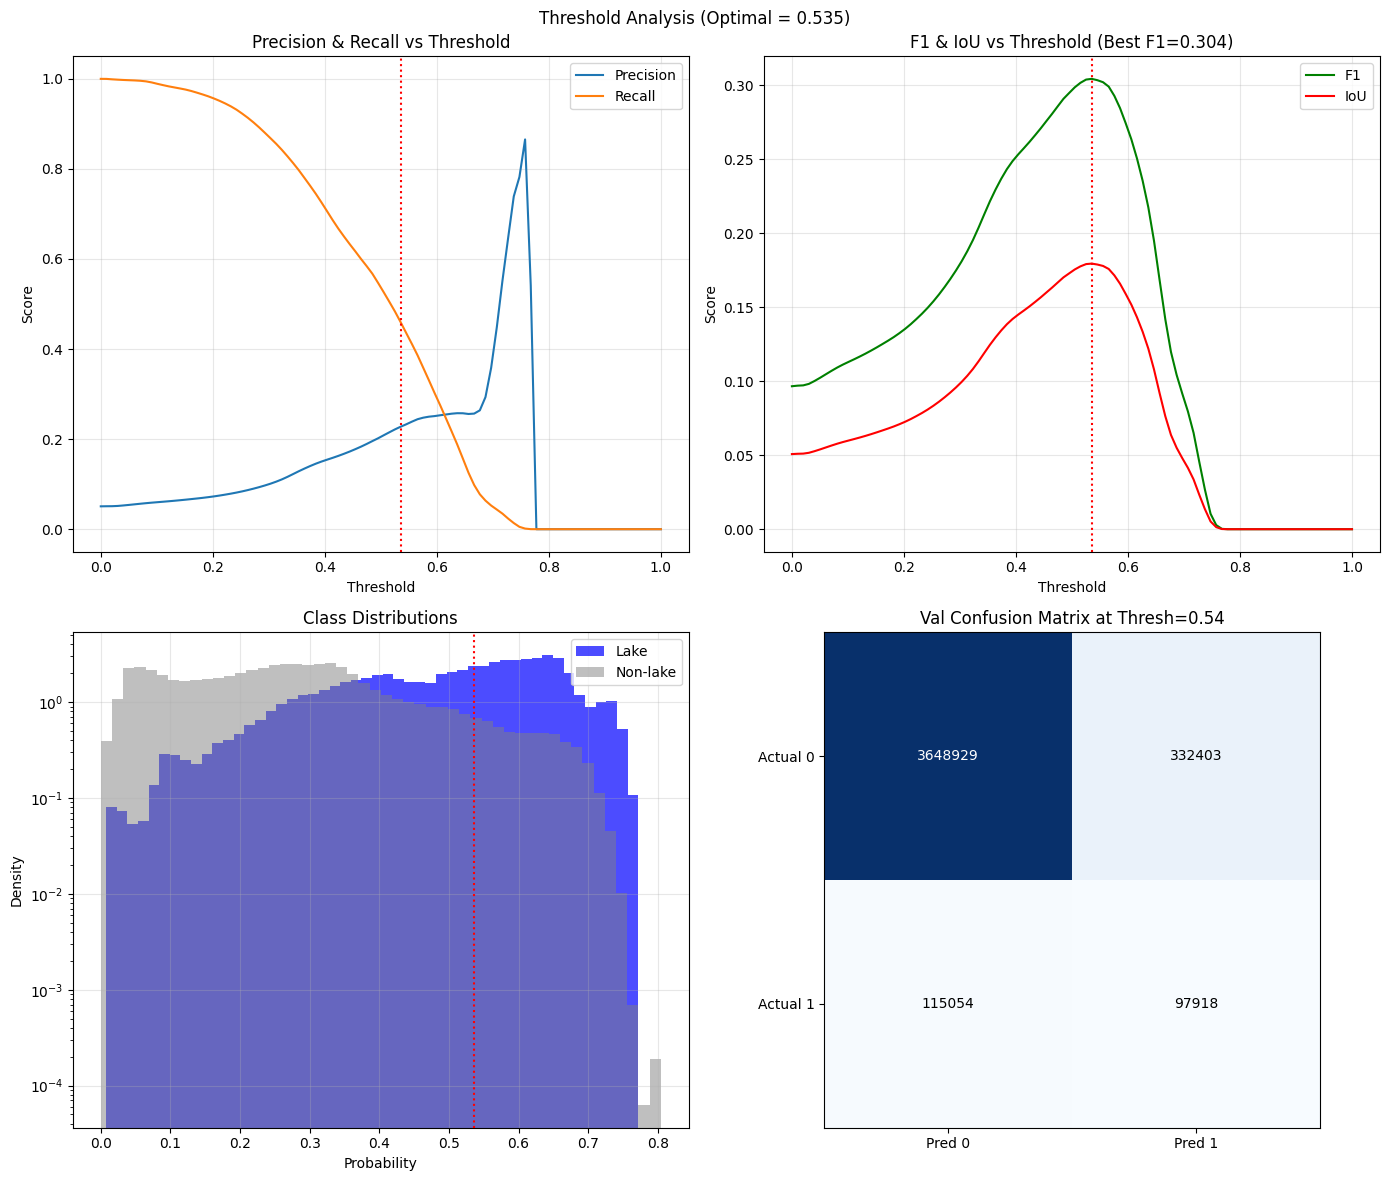


Optimal threshold: 0.535
  F1: 0.304, IoU: 0.180
  Precision: 0.228, Recall: 0.460


In [15]:
# ============================================
# BLOCK 6: THRESHOLD ANALYSIS
# ============================================

def get_threshold_metrics(model, loader, device, n_thresholds=100):
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            targets = y.cpu().numpy().flatten()
            all_probs.extend(probs); all_targets.extend(targets)
    all_probs = np.array(all_probs); all_targets = np.array(all_targets)
    thresholds = np.linspace(0, 1, n_thresholds)
    precision, recall, f1_scores, iou_scores = [], [], [], []
    for thresh in thresholds:
        preds = (all_probs > thresh).astype(float)
        tp = (preds * all_targets).sum()
        fp = (preds * (1 - all_targets)).sum()
        fn = ((1 - preds) * all_targets).sum()
        prec = tp / (tp + fp + 1e-6)
        rec = tp / (tp + fn + 1e-6)
        f1 = 2 * (prec * rec) / (prec + rec + 1e-6)
        iou = tp / (tp + fp + fn + 1e-6)
        precision.append(prec); recall.append(rec); f1_scores.append(f1); iou_scores.append(iou)
    return thresholds, np.array(precision), np.array(recall), np.array(f1_scores), np.array(iou_scores), all_probs, all_targets

def plot_threshold_analysis_4panel(model, val_loader, device, n_thresholds=100):
    thresholds, precision, recall, f1_scores, iou_scores, all_probs, all_targets = get_threshold_metrics(model, val_loader, device, n_thresholds)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    fig, axes = plt.subplots(2,2,figsize=(14,12))
    ax = axes[0,0]; ax.plot(thresholds, precision, label='Precision'); ax.plot(thresholds, recall, label='Recall')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score'); ax.set_title('Precision & Recall vs Threshold')
    ax.legend(); ax.grid(True, alpha=0.3); ax.axvline(x=optimal_threshold, color='red', linestyle=':')
    ax = axes[0,1]; ax.plot(thresholds, f1_scores, label='F1', color='green')
    ax.plot(thresholds, iou_scores, label='IoU', color='red')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score'); ax.set_title(f'F1 & IoU vs Threshold (Best F1={f1_scores[optimal_idx]:.3f})')
    ax.legend(); ax.grid(True, alpha=0.3); ax.axvline(x=optimal_threshold, color='red', linestyle=':')
    ax = axes[1,0]; ax.hist(all_probs[all_targets==1], bins=50, alpha=0.7, label='Lake', color='blue', density=True)
    ax.hist(all_probs[all_targets==0], bins=50, alpha=0.5, label='Non-lake', color='gray', density=True)
    ax.axvline(x=optimal_threshold, color='red', linestyle=':')
    ax.set_xlabel('Probability'); ax.set_ylabel('Density'); ax.set_title('Class Distributions')
    ax.legend(); ax.set_yscale('log'); ax.grid(True, alpha=0.3)
    ax = axes[1,1]; preds_opt = (all_probs > optimal_threshold).astype(float)
    tp = (preds_opt * all_targets).sum(); fp = (preds_opt * (1 - all_targets)).sum()
    fn = ((1 - preds_opt) * all_targets).sum(); tn = ((1 - preds_opt) * (1 - all_targets)).sum()
    cm = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(cm, cmap='Blues'); ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0','Pred 1']); ax.set_yticklabels(['Actual 0','Actual 1'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{int(cm[i,j])}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(f'Val Confusion Matrix at Thresh={optimal_threshold:.2f}')
    plt.suptitle(f'Threshold Analysis (Optimal = {optimal_threshold:.3f})')
    plt.tight_layout(); plt.show()
    print(f"\nOptimal threshold: {optimal_threshold:.3f}")
    print(f"  F1: {f1_scores[optimal_idx]:.3f}, IoU: {iou_scores[optimal_idx]:.3f}")
    print(f"  Precision: {precision[optimal_idx]:.3f}, Recall: {recall[optimal_idx]:.3f}")
    return optimal_threshold

optimal_threshold = plot_threshold_analysis_4panel(model, val_loader, device)

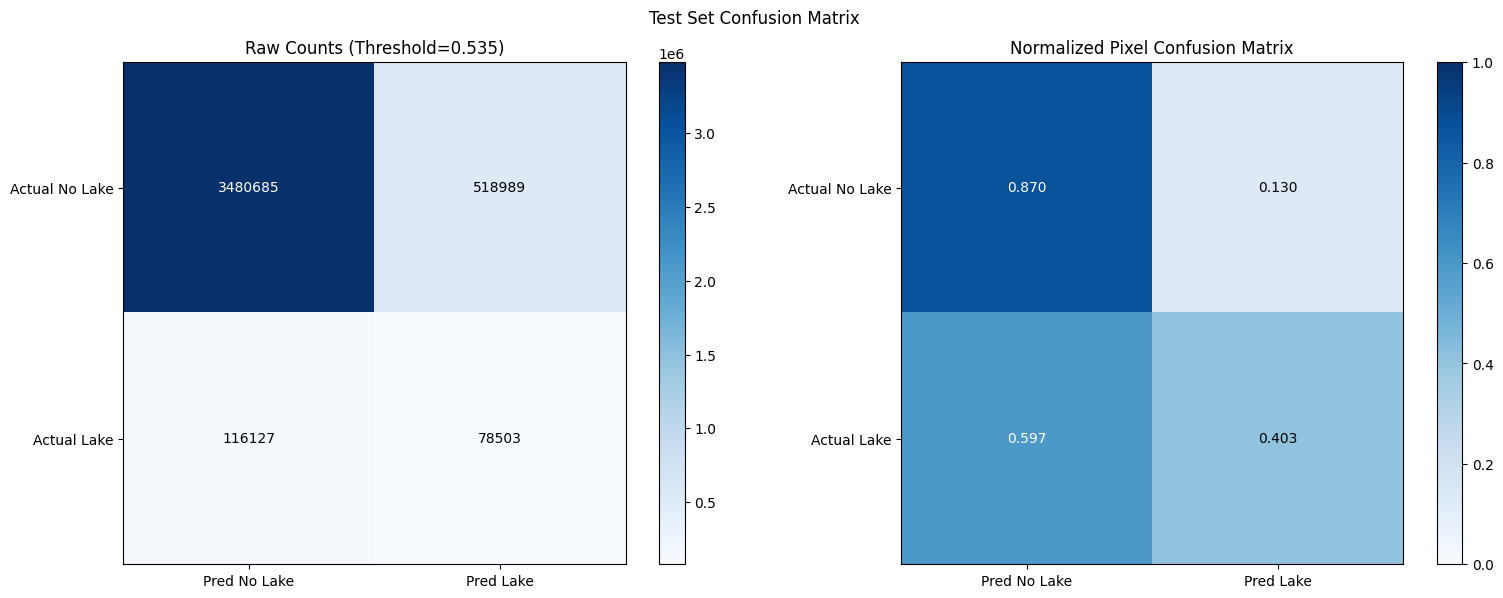


TEST SET RESULTS
Threshold: 0.535
TP: 78503, FP: 518989, FN: 116127, TN: 3480685
Lake Precision: 0.1314, Recall: 0.4033, F1: 0.1982
BG Precision: 0.9677, Recall: 0.8702, F1: 0.9164
Accuracy: 0.8486, Balanced Acc: 0.6368, IoU: 0.1100


In [16]:
# ============================================
# BLOCK 7: TEST CONFUSION MATRIX
# ============================================

@torch.no_grad()
def test_confusion_matrix_normalized(model, test_loader, device, threshold):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(y.cpu().numpy().flatten())
    all_preds = np.array(all_preds); all_targets = np.array(all_targets)
    cm = confusion_matrix(all_targets, all_preds)
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp

    # Class metrics
    lake_total = tp + fn
    lake_precision = tp / (tp + fp + 1e-6)
    lake_recall = tp / (lake_total + 1e-6)
    lake_f1 = 2 * (lake_precision * lake_recall) / (lake_precision + lake_recall + 1e-6)
    bg_total = tn + fp
    bg_precision = tn / (tn + fn + 1e-6)
    bg_recall = tn / (bg_total + 1e-6)
    bg_f1 = 2 * (bg_precision * bg_recall) / (bg_precision + bg_recall + 1e-6)
    accuracy = (tp + tn) / total
    balanced_acc = (lake_recall + bg_recall) / 2
    iou = tp / (tp + fp + fn + 1e-6)

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    ax = axes[0]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred No Lake','Pred Lake'])
    ax.set_yticklabels(['Actual No Lake','Actual Lake'])
    ax.set_title(f'Raw Counts (Threshold={threshold:.3f})')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{int(cm[i,j])}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

    ax = axes[1]

    # Normalize confidence matrix based on row sums
    row_sums = cm.sum(axis=1)
    cm_normalized = cm.astype('float') / row_sums[:, np.newaxis]

    im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred No Lake','Pred Lake'])
    ax.set_yticklabels(['Actual No Lake','Actual Lake'])
    ax.set_title('Normalized Pixel Confusion Matrix')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_normalized[i,j]:.3f}', ha='center', va='center',
                    color='white' if cm_normalized[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)
    plt.suptitle('Test Set Confusion Matrix')
    plt.tight_layout(); plt.show()

    # Print results
    print("\n" + "="*70)
    print("TEST SET RESULTS")
    print("="*70)
    print(f"Threshold: {threshold:.3f}")
    print(f"TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
    print(f"Lake Precision: {lake_precision:.4f}, Recall: {lake_recall:.4f}, F1: {lake_f1:.4f}")
    print(f"BG Precision: {bg_precision:.4f}, Recall: {bg_recall:.4f}, F1: {bg_f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}, Balanced Acc: {balanced_acc:.4f}, IoU: {iou:.4f}")
    return {'cm': cm, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn, 'lake_f1': lake_f1}

test_results = test_confusion_matrix_normalized(model, test_loader, device, optimal_threshold)

Lake name: Scott12
Original image index: 45
Patch location: y=0, x=0


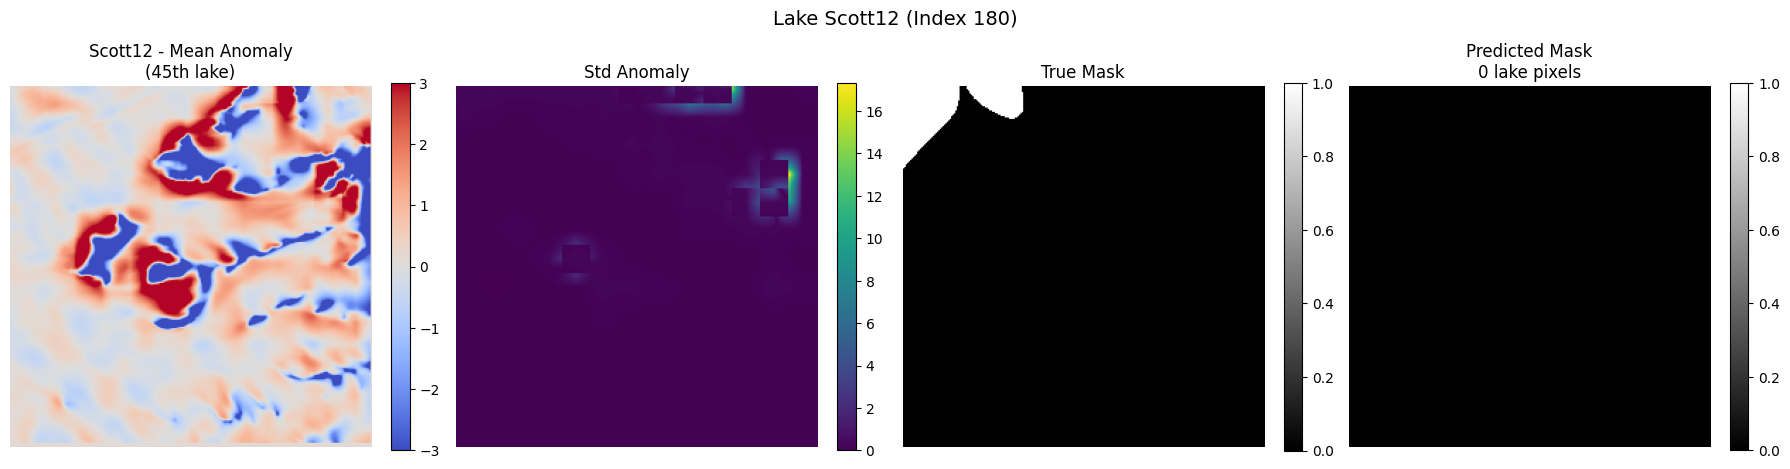


📊 Dice Score for this patch: 0.0000
   True lake pixels: 2183
   Predicted lake pixels: 0
   Overlap (TP): 0


In [ ]:
# ============================================
# PLOT MASKS FOR SPECIFIC LAKE IN TRAINING DATASET
# ============================================

# Set the index 
lake_index = 180

# Get the sample
X, y = train_dataset[lake_index]
patch_info = train_dataset.patches[lake_index]
original_idx = patch_info['idx']
row = train_df.iloc[original_idx]
lake_name = row['name']

print(f"Lake name: {lake_name}")
print(f"Original image index: {original_idx}")
print(f"Patch location: y={patch_info['y']}, x={patch_info['x']}")

# Get model prediction
model.eval()
with torch.no_grad():
    X_input = X.unsqueeze(0).to(device)
    logits = model(X_input)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred = (probs > 0.5).astype(float)

# Convert tensors for plotting
X_np = X.cpu().numpy()
y_np = y.squeeze().cpu().numpy()

# Create 4-panel plot (like your original plot_prediction)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Panel 1: Mean anomaly
im0 = axes[0].imshow(X_np[0], cmap='coolwarm', vmin=-3, vmax=3)
axes[0].set_title(f'{lake_name} - Mean Anomaly\n(45th lake)', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Panel 2: Std anomaly
im1 = axes[1].imshow(X_np[1], cmap='viridis')
axes[1].set_title('Std Anomaly', fontsize=12)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Panel 3: True mask
im2 = axes[2].imshow(y_np, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('True Mask', fontsize=12)
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

# Panel 4: Predicted mask
im3 = axes[3].imshow(pred, cmap='gray', vmin=0, vmax=1)
lake_pixels = pred.sum()
axes[3].set_title(f'Predicted Mask\n{lake_pixels:.0f} lake pixels', fontsize=12)
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.suptitle(f'Lake {lake_name} (Index {lake_index})', fontsize=14)
plt.tight_layout()
plt.show()

# Calculate Dice score
intersection = (pred * y_np).sum()
union = pred.sum() + y_np.sum()
dice = (2 * intersection + 1e-6) / (union + 1e-6)
print(f"Dice Score for this patch: {dice:.4f}")
print(f"True lake pixels: {y_np.sum():.0f}")
print(f"Predicted lake pixels: {lake_pixels:.0f}")
print(f"Overlap (TP): {intersection:.0f}")